In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import emcee
import scipy.stats
import corner

In [7]:
#full parameter bayesian estimate
data= np.load('transient.npy')

In [72]:
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot

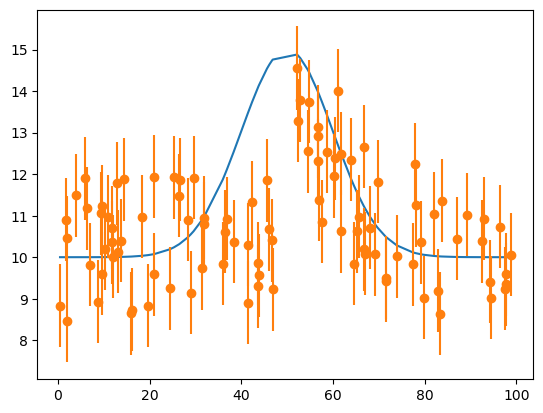

In [73]:
#Define a new model
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0))) #possible model
    
def gaussian(theta,t):
    A,b,t0,sigmaW=theta     
    return b+A*np.exp(-(((t-t0)/sigmaW)**2 ) / 2)

#fit this new model with the data

theta_guess = 5,10,50,10
t=data[:,0]
model=gaussian(theta_guess,t)
plt.plot(t,model)
plt.errorbar(data[:,0], data[:,1], data[:,2], fmt='o')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()

#we decided to take sigma_w as a log uniform from o to 100
sigmaWmin, sigmaWmax =np.exp(0),np.exp(2);

In [74]:
def loglike(theta, data, model):
    x, y, sigma = data[:,0],data[:,1],data[:,2]
    if model =='burst':
        y_fit = burst(theta, x)
    elif model == 'gaussian':
        y_fit = gaussian(theta, x)
    return -0.5 * np.sum((y-y_fit)**2/(sigma**2))

def ptform(u,model):
    x = np.array(u) 
    x[0] = Amin + u[0] * (Amax - Amin)
    x[1] = bmin + u[1] * (bmax - bmin)
    x[2] = t0min + u[2] * (t0max - t0min)
   
    if model == 'burst':
        x[3] = np.exp(np.log(alphamin) + u[3] * (np.log(alphamax) - np.log(alphamin)))
    elif model == 'gaussian':
        x[3] = np.exp(np.log(sigmaWmin) + u[3] * (np.log(sigmaWmax) - np.log(sigmaWmin)))
        
    return x

In [75]:
ndim = 4
sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'burst'],ptform_args=['burst'],nlive=100) #lets see again this solution
sampler.run_nested()
sresults = sampler.results

C:\Users\kevin\AppData\Local\Temp\ipykernel_10660\1503405379.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0))) #possible model
C:\Users\kevin\AppData\Local\Temp\ipykernel_10660\1503405379.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0))) #possible model
371it [00:00, 708.54it/s, bound: 0 | nc: 99 | ncall: 3694 | eff(%): 10.043 | loglstar:   -inf < -165.244 <    inf | logz: -173.120 +/-  0.277 | dlogz: 89.834 >  0.109]    C:\Users\kevin\AppData\Local\Temp\ipykernel_10660\1503405379.py:3: RuntimeWarning: overflow encountered in exp
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0))) #possible model
C:\Users\kevin\AppData\Local\Temp\ipykernel_10660\1503405379.py:3: RuntimeWarning: overflow encountered in multiply
  return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0))) #possible model
C:\Users\kevin\AppData\Local\Temp\ipykernel_10660\1503405379.py:3: RuntimeWarning: overflow encountered

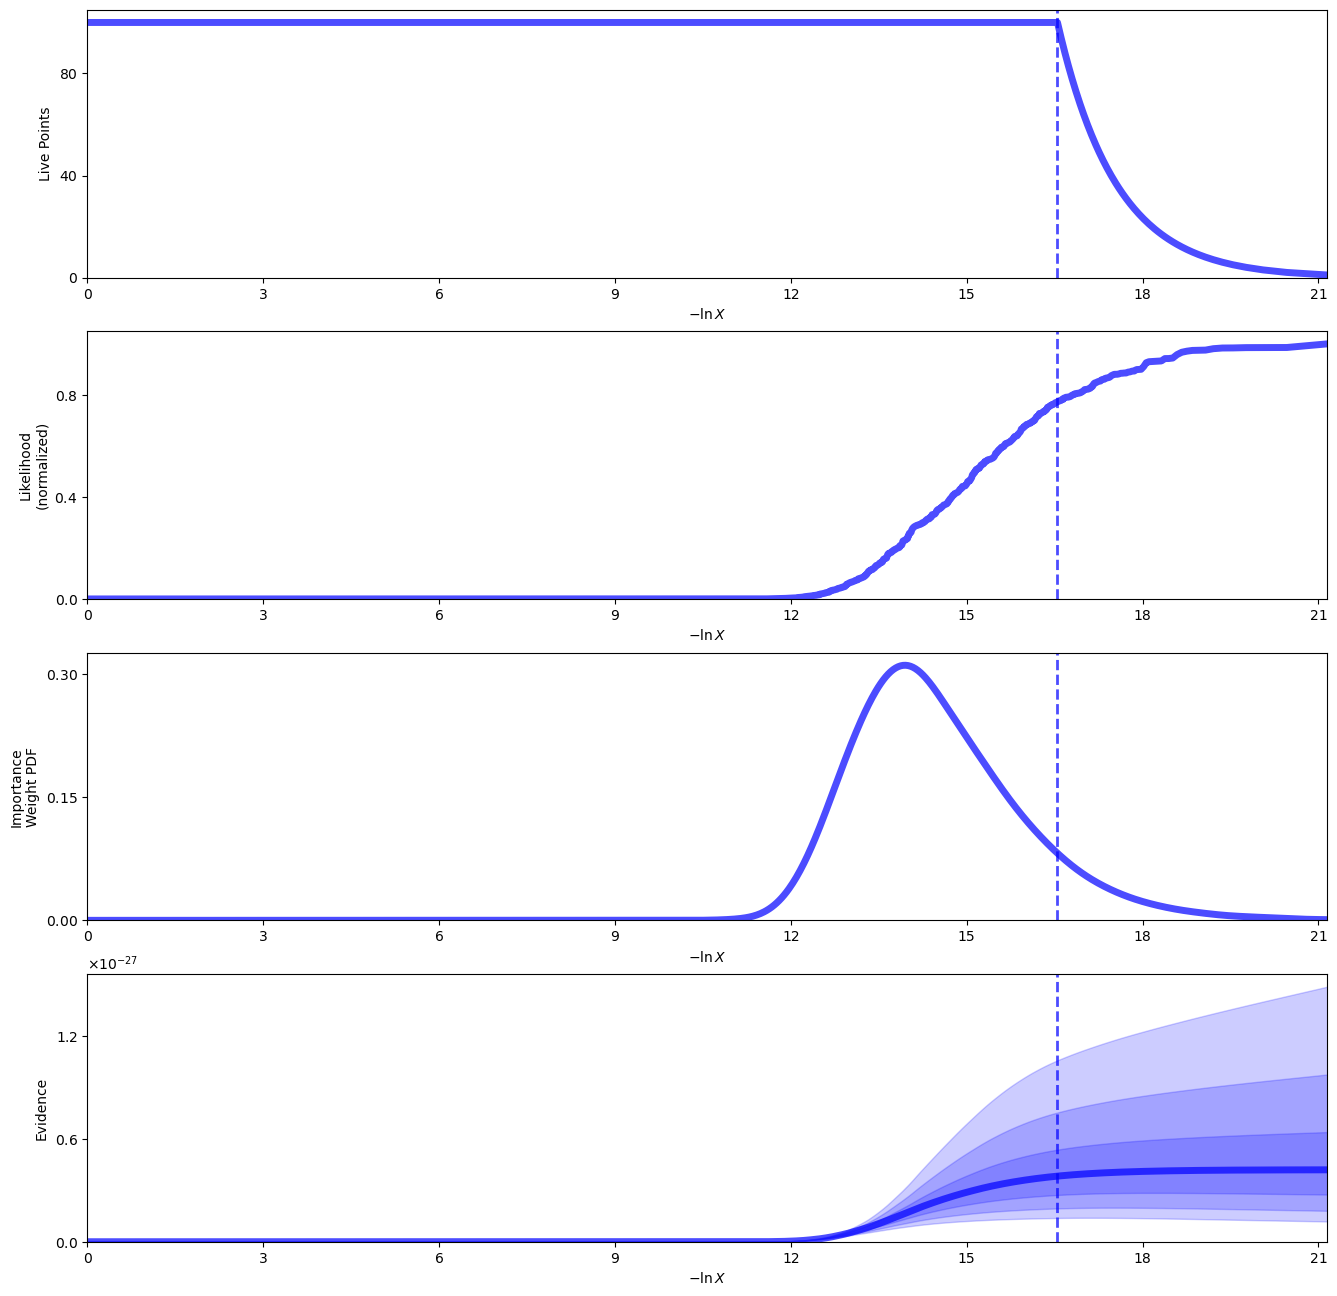

In [76]:
rfig, raxes = dyplot.runplot(sresults);

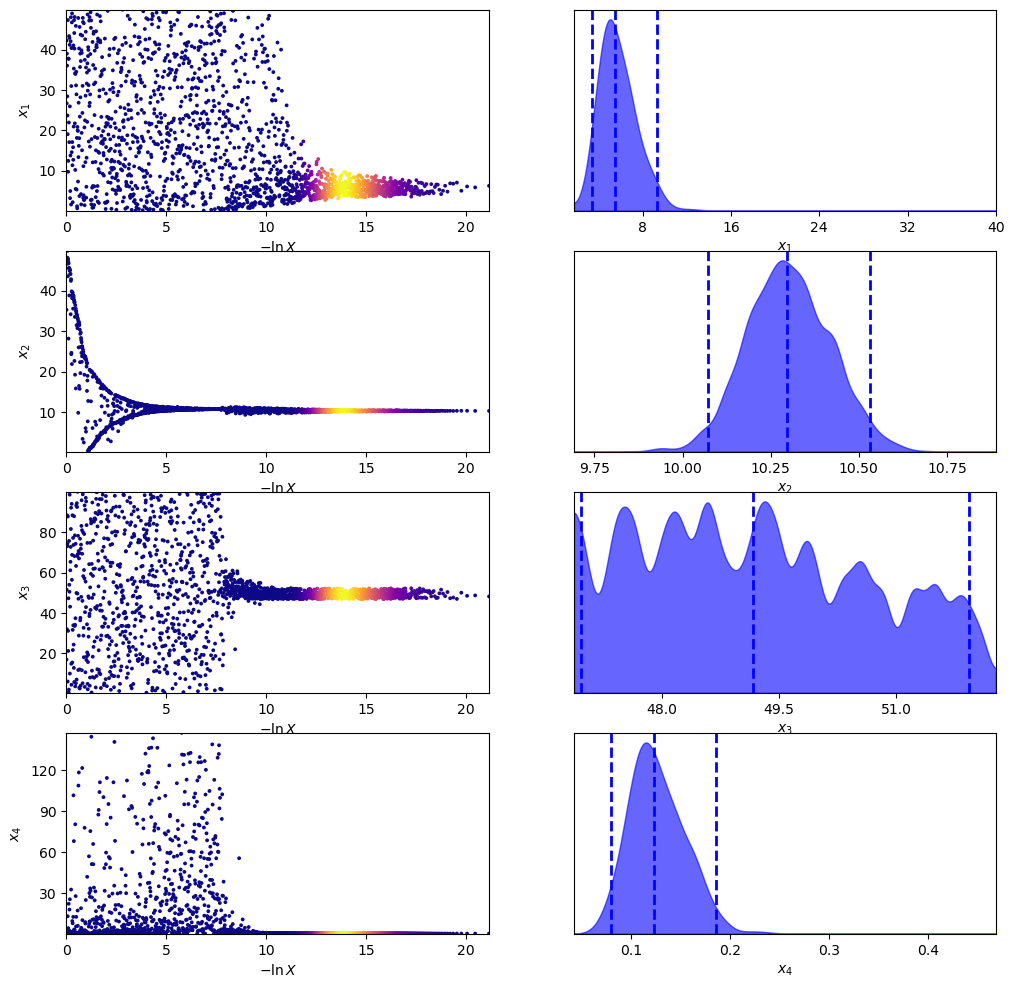

In [77]:
tfig, taxes = dyplot.traceplot(sresults) #control some of the outputs 

In [95]:
#lets see the new numbers with this new method
samples = sresults.samples
weights = np.exp(sresults.logwt - sresults.logz[-1])

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.05, 0.95, 0.5], weights=weights) for samps in samples.T]

# Compute mean.
mean, cov = dyfunc.mean_and_cov(samples, weights)

labels = ["A","b","t0","alpha"]
for i,l in enumerate(labels):
    print(l+"   "+str(quantiles[i][2])+" +"+str(quantiles[i][1]-quantiles[i][2])+" -"+str(quantiles[i][2]-quantiles[i][0]))

A   5.431152274673863 +3.2784455636959535 -1.829129381995104
b   10.296478594511427 +0.20350587432758793 -0.18093351798400903
t0   49.172743348543484 +2.602918839555173 -2.104262039706313
alpha   0.12271644761960852 +0.052857119374535175 -0.03738818780135454


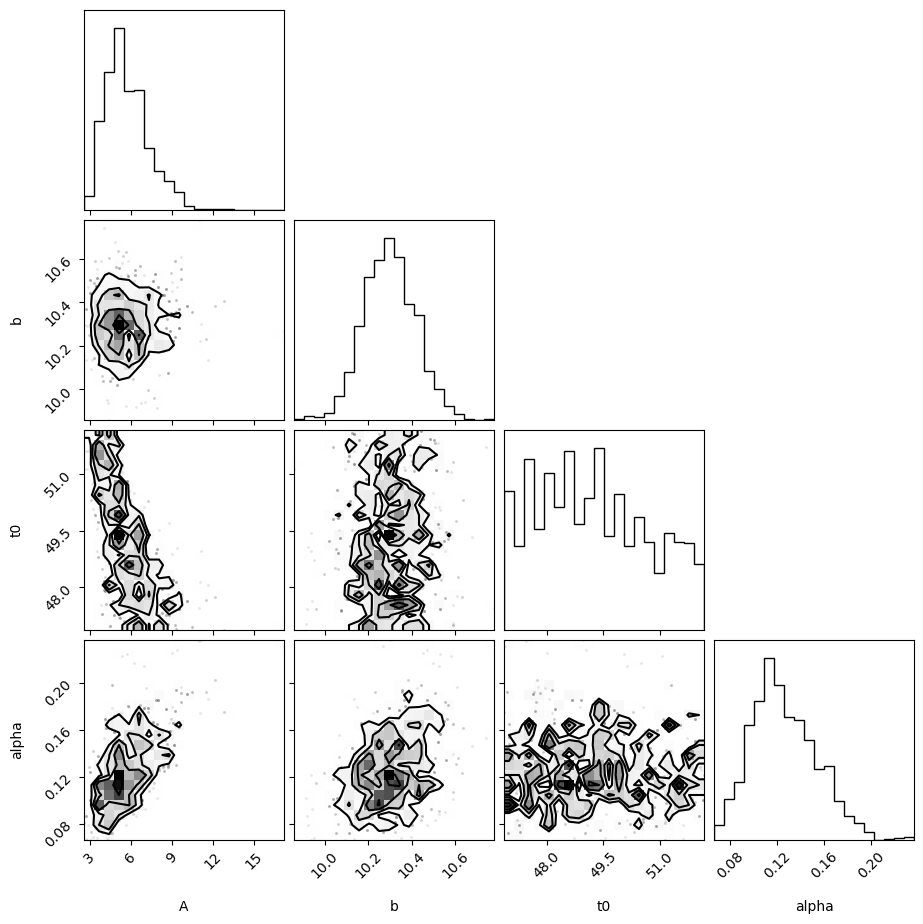

In [86]:
samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [87]:
sampler2 = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'gaussian'],ptform_args=['gaussian'],nlive=100)
sampler2.run_nested()
sresults2 = sampler2.results

405it [00:00, 447.51it/s, bound: 3 | nc: 7 | ncall: 3980 | eff(%): 10.176 | loglstar:   -inf < -312.068 <    inf | logz: -321.382 +/-  0.303 | dlogz: 239.544 >  0.109]   C:\Users\kevin\anaconda3\Lib\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
473it [00:01, 240.43it/s, bound: 8 | nc: 10 | ncall: 4770 | eff(%):  9.916 | loglstar:   -inf < -194.544 <    inf | logz: -203.572 +/-  0.294 | dlogz: 128.442 >  0.109]C:\Users\kevin\anaconda3\Lib\site-packages\dynesty\bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uni

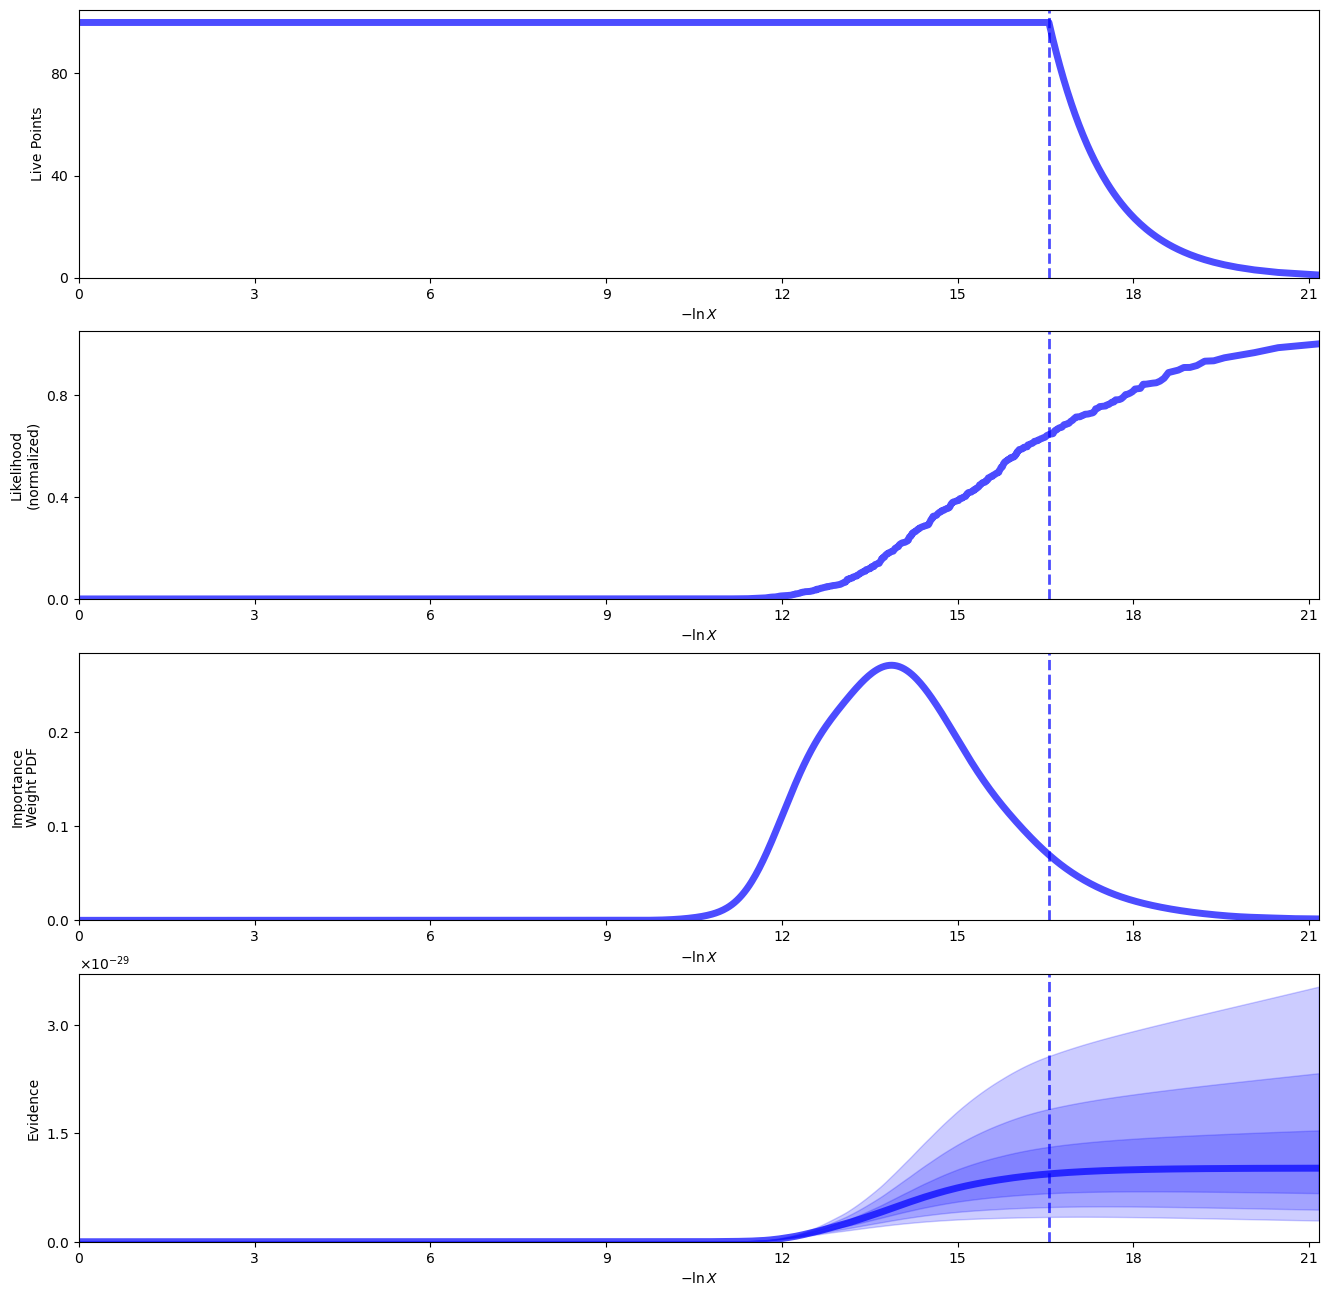

In [89]:
rfig, raxes = dyplot.runplot(sresults2);

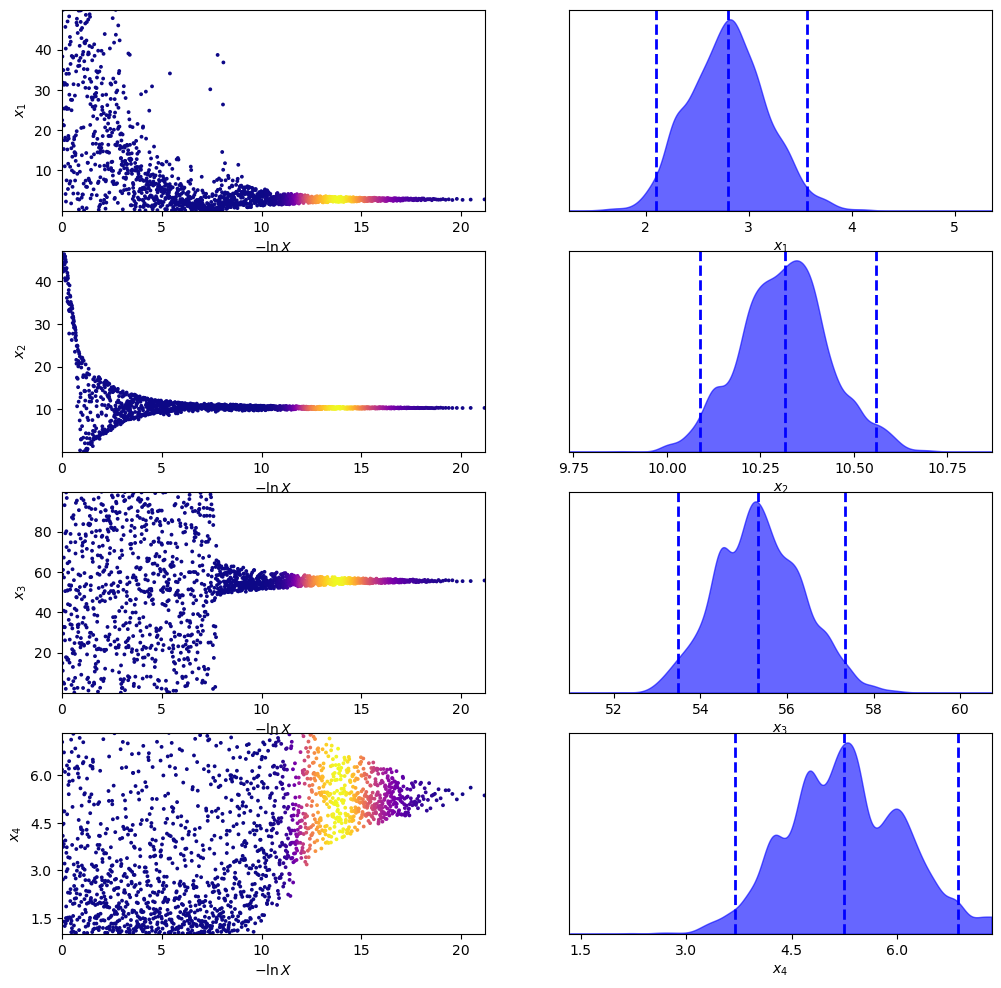

In [88]:
tfig, taxes = dyplot.traceplot(sresults2)

In [96]:
samples = sresults2.samples 
weights = np.exp(sresults2.logwt - sresults2.logz[-1])

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.05, 0.95, 0.5], weights=weights) for samps in samples.T]

# Compute mean.
mean, cov = dyfunc.mean_and_cov(samples, weights)

labels = ["A","b","t0","alpha"]
for i,l in enumerate(labels):
    print(l+"   "+str(quantiles[i][2])+" +"+str(quantiles[i][1]-quantiles[i][2])+" -"+str(quantiles[i][2]-quantiles[i][0]))

A   2.794394278211564 +0.6300004124388909 -0.5748248414634687
b   10.316560283655694 +0.19492223987139035 -0.19697621939254262
t0   55.322006646016085 +1.7094681362910649 -1.5901783094097937
alpha   5.238945277122975 +1.3583644306420952 -1.2917929597012745


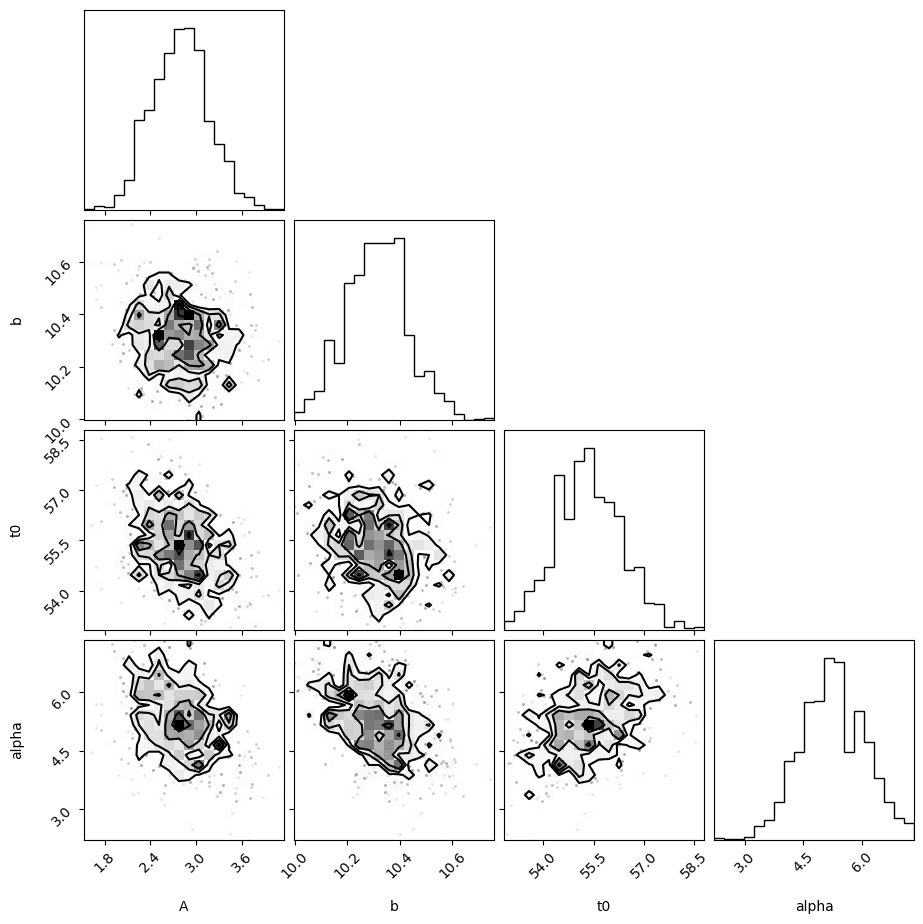

In [97]:
samples_equal2 = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal2,labels=labels);

In [94]:
f=np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])
print('The rate between the evidence of the model burst vs gaussian is' +' '+ str(f))

The rate between the evidence of the model burst vs gaussian is 41.2413737927806


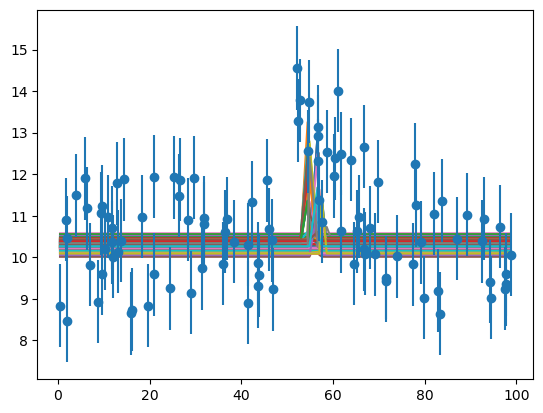

In [98]:
chosen_random=samples_equal2[np.random.choice(len(emcee_trace),size=100)]

for parameters in chosen_random:
    t=data[:,0]
    x=burst(parameters,t)
    plt.plot(t,x)

plt.errorbar(data[:,0], data[:,1], data[:,2], fmt='o')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend();

In [175]:
#The burst model one is prefered over the gaussian